# Xmatch con TESS

We analyzed the distribution of the closest and farthest counterparts in cases where two matches were found. Additionally, we examined the galactic distribution of stars with two counterparts.

Based on the distance distribution and the galactic distribution of double matches, the vast majority are located in the densest regions, so it is expected to have some degree of crowding.

Next, we assigned a flag to indicate the number of counterparts and retained the multiple TIC matches.

Finally, we considered the closest star as the original TIC source.

A total of 22 stars were found to be duplicated and have an identifier in 2MASS. In the worst-case scenario, up to 4% of the multiple matches could be contaminated.

In [ ]:
from astroquery.vizier import Vizier
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import os

# Root para datos pesados (descargas TESS + outputs tpfplotter).
# Si el disco externo no esta montado, cae al directorio actual.
DATA_ROOT = "/Volumes/T7/MassiveStarVariability"
if not os.path.isdir(DATA_ROOT):
    DATA_ROOT = os.getcwd()
print(f"DATA_ROOT = {DATA_ROOT}")


DATA_ROOT = /Volumes/T7/MassiveStarVariability


In [ ]:
df = pd.read_csv("train_number_M.csv")

In [ ]:
df = df.loc[(df['categorical_label']!=7) & (df["Train_8"]=="train")].reset_index(drop=True)

In [ ]:
df = df.drop_duplicates(subset="ID")

In [ ]:
df

,ID,RA,DEC,types,database,field,Subtype,per,error,obs_eliminadas,...,ra_deg,dec_deg,GroupID,GroupSize,Train_8,categorical_label,aug,count,bins,g
0,OGLE-LMC-LPV-14673,05:03:50.14,-69:17:29.0,lpv,3,lmc,SRV,146.7100,1,4.0,...,75.958917,-69.291389,NaN,NaN,train,5,0.0,1,NaN,111.035086
1,OGLE-LMC-LPV-58871,05:27:57.94,-69:05:25.7,lpv,3,lmc,OSARG,81.0300,1,0.0,...,81.991417,-69.090472,NaN,NaN,train,5,0.0,1,NaN,35.871862
2,OGLE-SMC-LPV-13015,00:57:58.45,-72:43:25.4,lpv,3,smc,OSARG,19.1450,1,4.0,...,14.493542,-72.723722,NaN,NaN,train,5,0.0,1,NaN,16.008772
3,OGLE-SMC-LPV-19325,01:23:50.15,-73:39:03.7,lpv,3,smc,OSARG,15.3190,1,2.0,...,20.958958,-73.651028,NaN,NaN,train,5,0.0,1,NaN,10.494013
4,OGLE-BLG-LPV-206481,18:05:39.79,-27:47:34.4,lpv,3,blg,SRV,55.4800,1,0.0,...,271.415792,-27.792889,NaN,NaN,train,5,0.0,1,NaN,6.632149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309170,OGLE-BLG-LPV-174086,18:00:46.29,-27:29:53.5,lpv,3,blg,SRV,91.7800,1,0.0,...,270.192875,-27.498194,NaN,NaN,train,5,0.0,1,NaN,4.810307
309171,OGLE-BLG-LPV-174090,18:00:46.34,-34:16:17.4,lpv,3,blg,OSARG,10.1700,1,1.0,...,270.193083,-34.271500,NaN,NaN,train,5,0.0,1,NaN,7.253474
309172,OGLE-BLG-LPV-174447,18:00:49.08,-29:55:03.7,lpv,3,blg,SRV,212.8000,1,0.0,...,270.204500,-29.917694,NaN,NaN,train,5,0.0,1,NaN,103.803068
309173,OGLE-BLG-LPV-174294,18:00:47.90,-29:34:00.5,lpv,3,blg,OSARG,843.7000,1,0.0,...,270.199583,-29.566806,NaN,NaN,train,5,0.0,1,NaN,507.899259


In [ ]:
df.groupby("field").count()

,ID,RA,DEC,types,database,Subtype,per,error,obs_eliminadas,amplitud,...,ra_deg,dec_deg,GroupID,GroupSize,Train_8,categorical_label,aug,count,bins,g
field,,,,,,,,,,,,,,,,,,,,,
blg,197943,197943,197943,197943,197943,175509,197943,197943,197943,197943,...,197943,197943,0,0,197943,197943,197943,197943,0,197943
gd,37104,37104,37104,37104,37104,37102,37104,37104,37104,37104,...,37104,37104,0,0,37104,37104,37104,37104,0,37104
lmc,59584,59584,59584,59584,59584,57034,59584,59584,59584,59584,...,59584,59584,0,0,59584,59584,59584,59584,0,59584
smc,14544,14544,14544,14544,14544,13942,14544,14544,14544,14544,...,14544,14544,0,0,14544,14544,14544,14544,0,14544


In [ ]:
import pandas as pd
import numpy as np
from astropy.table import Table, vstack
from astroquery.xmatch import XMatch
from astropy.coordinates import SkyCoord
import astropy.units as u
from tqdm import tqdm

# -------------------------------------------------------------
# 1) Convertir RA/DEC sexagesimal -> grados decimales
# -------------------------------------------------------------
# Si df["RA"], df["DEC"] vienen como "05:03:50.14", "-69:17:29.0"
coords = SkyCoord(
    ra=df["RA"].values,
    dec=df["DEC"].values,
    unit=(u.hourangle, u.deg)   # RA en horas:min:sec, DEC en grados:min:sec
)

df["ra_deg"]  = coords.ra.deg
df["dec_deg"] = coords.dec.deg

# Catálogo principal con columnas en grados
main_catalog = df[["ID","database", "ra_deg", "dec_deg"]].rename(
    columns={"ra_deg": "ra", "dec_deg": "dec"}
)

# -------------------------------------------------------------
# 2) XMatch por chunks
# -------------------------------------------------------------
def xmatch_in_chunks(catalog_df, chunk_size=50000, max_dist_arcsec=2):
    """
    Hace XMatch contra TIC v8 en chunks para evitar timeouts.
    """
    results = []
    n = len(catalog_df)
    n_chunks = int(np.ceil(n / chunk_size))

    for i in tqdm(range(n_chunks), desc="XMatch chunks"):
        start = i * chunk_size
        end   = min(start + chunk_size, n)
        chunk = catalog_df.iloc[start:end]

        cat_astropy = Table.from_pandas(chunk)

        try:
            res = XMatch.query(
                cat1=cat_astropy,
                cat2="vizier:IV/38/tic",
                max_distance=max_dist_arcsec * u.arcsec,
                colRA1="ra",
                colDec1="dec",
            )
            if len(res) > 0:
                results.append(res)
        except Exception as e:
            print(f"⚠️ Error en chunk {i} ({start}:{end}): {e}")
            continue

    if results:
        return vstack(results)
    else:
        return Table()

# Ejecutar
result = xmatch_in_chunks(main_catalog, chunk_size=50000, max_dist_arcsec=2)

# Guardar para no perder el trabajo
result.write("xmatch_tic_result.fits", overwrite=True)
print(f"Total de matches: {len(result)}")

XMatch chunks: 100%|██████████| 9/9 [10:12<00:00, 68.10s/it]


Total de matches: 593145


In [ ]:
import fitsio
import pandas as pd
import numpy as np

# Leer con fitsio
data = fitsio.read('xmatch_tic_result.fits')

# Convertir el array estructurado a little-endian ANTES de pasarlo a pandas
data = data.astype(data.dtype.newbyteorder('='))

df = pd.DataFrame(data)
print(df.head())

    angDist                  ID  database         ra        dec        TIC  \
0  0.093022  OGLE-LMC-LPV-14673         3  75.958917 -69.291389   30844876   
1  0.955612  OGLE-LMC-LPV-14673         3  75.958917 -69.291389  678648437   
2  1.329827  OGLE-LMC-LPV-14673         3  75.958917 -69.291389  678648330   
3  1.500429  OGLE-LMC-LPV-14673         3  75.958917 -69.291389  678648908   
4  0.028721  OGLE-LMC-LPV-58871         3  81.991417 -69.090472  279957753   

       RAdeg      DEdeg  HIP TYC  ... Mass s_Mass         Dist       s_Dist  \
0  75.958989 -69.291386    0      ...  NaN    NaN  5579.589844  1086.670044   
1  75.958727 -69.291646    0      ...  NaN    NaN          NaN          NaN   
2  75.957890 -69.291321    0      ...  NaN    NaN  2893.260010   909.530029   
3  75.959037 -69.290974    0      ...  NaN    NaN  1647.739990   727.409973   
4  81.991438 -69.090470    0      ...  NaN    NaN  8501.309570  1379.339966   

   E(B-V)  s_E(B-V)       e_Dist       E_Dist     RAOdeg

In [ ]:
df.drop_duplicates(subset="ID")

,angDist,ID,database,ra,dec,TIC,RAdeg,DEdeg,HIP,TYC,...,Mass,s_Mass,Dist,s_Dist,E(B-V),s_E(B-V),e_Dist,E_Dist,RAOdeg,DEOdeg
0,0.093022,OGLE-LMC-LPV-14673,3,75.958917,-69.291389,30844876,75.958989,-69.291386,0,,...,NaN,NaN,5579.589844,1086.670044,0.1366,0.0000,955.609985,1217.719971,75.959019,-69.291386
4,0.028721,OGLE-LMC-LPV-58871,3,81.991417,-69.090472,279957753,81.991438,-69.090470,0,,...,NaN,NaN,8501.309570,1379.339966,0.6538,NaN,1243.900024,1514.790039,81.991459,-69.090467
6,0.060225,OGLE-SMC-LPV-13015,3,14.493542,-72.723722,181886827,14.493496,-72.723712,0,,...,NaN,NaN,5994.279785,1077.930054,0.3006,NaN,943.390015,1212.469971,14.493508,-72.723718
7,0.084753,OGLE-SMC-LPV-19325,3,20.958958,-73.651028,183801922,20.958937,-73.651005,0,,...,NaN,NaN,6427.660156,1160.439941,0.0436,NaN,1020.229980,1300.660034,20.958952,-73.651010
8,0.349177,OGLE-BLG-LPV-206481,3,271.415792,-27.792889,407725585,271.415692,-27.792849,0,,...,NaN,NaN,7688.620117,3389.659912,0.6415,0.0326,2661.540039,4117.779785,271.415663,-27.792879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433136,0.060978,OGLE-BLG-LPV-174086,3,270.192875,-27.498194,195698366,270.192875,-27.498211,0,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,270.192875,-27.498211
433137,0.057167,OGLE-BLG-LPV-174090,3,270.193083,-34.271500,264351853,270.193065,-34.271495,0,,...,NaN,NaN,4935.399902,2636.909912,0.5048,0.0222,1750.359985,3523.459961,270.193055,-34.271518
433138,0.095478,OGLE-BLG-LPV-174447,3,270.204500,-29.917694,195873337,270.204481,-29.917715,0,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,270.204481,-29.917715
433140,0.035796,OGLE-BLG-LPV-174294,3,270.199583,-29.566806,195798626,270.199578,-29.566815,0,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,270.199578,-29.566815


In [ ]:
#df = result#.to_pandas()

In [ ]:
coord = SkyCoord(ra=df["ra"].values, dec=df["dec"].values, unit=(u.deg, u.deg)).galactic
candidates_l_rad = coord.l.radian
candidates_l_rad[candidates_l_rad > np.pi] -= 2. * np.pi
candidates_b_rad = coord.b.radian

df["l"] = candidates_l_rad*u.radian.to(u.deg)
df["b"] = candidates_b_rad*u.radian.to(u.deg)

In [ ]:
df_singled = df[df['ID'].map(df['ID'].value_counts()) == 1].reset_index(drop=True)
df_duplicated = df[df['ID'].map(df['ID'].value_counts()) == 2].reset_index(drop=True)
df_triplicated = df[df['ID'].map(df['ID'].value_counts()) == 3].reset_index(drop=True)


In [ ]:
df_duplicated["nearest"] = (df_duplicated.groupby("ID")["angDist"]
                                    .transform(lambda x: (x == x.min()).astype(int)))


In [ ]:
#singled, duplicated,triplicated
len(df_singled.drop_duplicates(subset="ID")),len(df_duplicated.drop_duplicates(subset="ID")),len(df_triplicated.drop_duplicates(subset="ID"))

(164392, 83534, 20574)

<Axes: xlabel='angDist', ylabel='Count'>

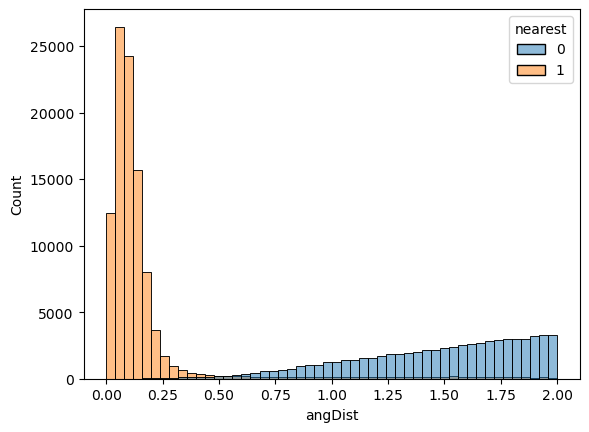

In [ ]:
sns.histplot(data=df_duplicated,x="angDist",hue="nearest",bins=50)

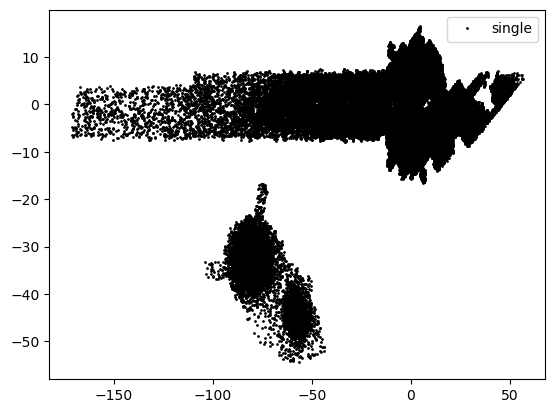

In [ ]:
plt.plot(df_singled["l"],df_singled["b"],"k.",ms=2,label='single')
plt.legend()

In [ ]:
df_singled.to_csv("catalogs/1_OGLEXTessV8.csv",index=False)

# Download light curves from TIC information

## Search TESS-SPOC

In [ ]:
from astroquery.mast import Observations
import pandas as pd
from astropy.io import fits
import re

### Masivas x TESS

In [ ]:
df = pd.read_csv("catalogs/1_OGLEXTessV8.csv")

/var/folders/b0/_shrs6sx2x5gt6jg55ztqpdr0000gn/T/ipykernel_12903/1084523451.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("catalogs/1_OGLEXTessV8.csv")


In [ ]:
tic_ids = df["TIC"].values

In [ ]:
from astropy.table import vstack

def get_tess_spoc_products(tic_ids, batch_size=50):
    all_products = []
    batches = [tic_ids[i:i+batch_size] for i in range(0, len(tic_ids), batch_size)]

    for k, batch in enumerate(batches):
        print(f"Batch {k+1}/{len(batches)}...", end="\r")
        try:
            obs = Observations.query_criteria(
                provenance_name="TESS-SPOC",
                target_name=batch,
                dataproduct_type='TIMESERIES'
            )
            if len(obs) == 0:
                continue
            products = Observations.get_product_list(obs)

            # Filtra solo _lc.fits
            lc_mask = ['_lc.fits' in p for p in products['productFilename']]
            lc_products = products[lc_mask]

            if len(lc_products) > 0:
                all_products.append(lc_products)
        except Exception as e:
            print(f"\nError batch {k+1}: {e}")

    print(f"\nListo: {len(all_products)} batches con datos")
    return vstack(all_products) if all_products else None

data_products = get_tess_spoc_products(tic_ids, batch_size=500)



Batch 329/329...
Listo: 123 batches con datos


In [ ]:
# Convertir a pandas y extraer TIC, sector, filename
data_products_df = data_products.to_pandas()
data_products_df["TIC"] = data_products_df["productFilename"].str.split("_").str[4].str.split("-").str[0].astype(int)
data_products_df["sector"] = data_products_df["productFilename"].str.split("_").str[4].str.split("-").str[1].str[1:].astype(int)
data_products_df = data_products_df[["TIC", "sector", "dataURI", "productFilename"]]

# Guardar CSV con una fila por lightcurve
data_products_df.to_csv("catalogs/2_OGLEXTessV8_LC.csv", index=False)

# Agregar sector_list y filenames al catálogo original
tic_sectors = (
    data_products_df.groupby("TIC")
    .agg(
        sector_list=("sector", list),
        filenames=("productFilename", list)
    )
    .reset_index()
)

# Idempotente: elimina sector_list/filenames previos para que re-ejecutar
# esta celda no genere columnas duplicadas con sufijos _x/_y al re-mergear.
df = df.drop(columns=["sector_list", "filenames"], errors="ignore")
df = df.merge(tic_sectors, how="left", on="TIC")
df.to_csv("catalogs/1_OGLEXTessV8.csv", index=False)

print(f"Estrellas con datos: {df['sector_list'].notna().sum()} / {len(df)}")
print(f"Total lightcurves: {len(data_products_df)}")







Estrellas con datos: 5369 / 13482
Total lightcurves: 13483


In [ ]:
df = pd.read_csv("catalogs/1_OGLEXTessV8.csv")

In [ ]:
df.loc[df["filenames"].notna()].to_csv("catalogs/1_OGLEXTessV8.csv", index=False)

## Download parallel LC

In [ ]:
import pandas as pd
from astroquery.mast import Observations
import os
import re

In [ ]:
data_products_df =  pd.read_csv("catalogs/2_OGLEXTessV8_LC.csv")

In [ ]:
import os
import concurrent.futures
from astroquery.mast import Observations

DIR = f"{DATA_ROOT}/ogle_download"
os.makedirs(DIR, exist_ok=True)

def download_file(dataURI):
    filename = dataURI.split('/')[-1]
    file_path = os.path.join(DIR, filename)
    if os.path.isfile(file_path):
        return f"EXISTS: {filename}"
    try:
        Observations.download_file(dataURI, local_path=file_path)
        return f"OK: {filename}"
    except Exception as e:
        return f"ERROR: {filename} - {e}"

data_products_df = pd.read_csv("catalogs/2_OGLEXTessV8_LC.csv")
uris = data_products_df["dataURI"].tolist()

with concurrent.futures.ThreadPoolExecutor(max_workers=25) as executor:
    futures = {executor.submit(download_file, uri): uri for uri in uris}
    for i, future in enumerate(concurrent.futures.as_completed(futures)):
        print(f"[{i+1}/{len(uris)}] {future.result()}", end="\r")

print("\nDescarga completada.")


 [Done]3483] OK: hlsp_tess-spoc_tess_phot_0000000429749401-s0044_tess_v1_lc.fits
 [Done]3483] OK: hlsp_tess-spoc_tess_phot_0000000030110048-s0062_tess_v1_lc.fits
 [Done]3483] OK: hlsp_tess-spoc_tess_phot_0000000445542388-s0058_tess_v1_lc.fits
 [Done]3483] OK: hlsp_tess-spoc_tess_phot_0000000406964759-s0078_tess_v1_lc.fits
 [Done]3483] OK: hlsp_tess-spoc_tess_phot_0000000114075839-s0080_tess_v1_lc.fits
 [Done]3483] OK: hlsp_tess-spoc_tess_phot_0000000341508675-s0066_tess_v1_lc.fits
 [Done]3483] OK: hlsp_tess-spoc_tess_phot_0000000332158408-s0058_tess_v1_lc.fits
 [Done]3483] OK: hlsp_tess-spoc_tess_phot_0000000030110048-s0065_tess_v1_lc.fits
 [Done]3483] OK: hlsp_tess-spoc_tess_phot_0000000234752466-s0066_tess_v1_lc.fits

 [Done]3483] OK: hlsp_tess-spoc_tess_phot_0000000030110048-s0061_tess_v1_lc.fits
 [Done]3483] OK: hlsp_tess-spoc_tess_phot_0000000412519841-s0061_tess_v1_lc.fits
 [Done]3483] OK: hlsp_tess-spoc_tess_phot_0000000239718749-s0019_tess_v1_lc.fits
 [Done]3483] OK: hlsp_tess-

## Revisar si se descargaron todos los datos y esta a corde con lo que esperamos de los catalogos

In [ ]:
import pandas as pd
import os
from astropy.io import fits
import seaborn as sns
import re
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from pandarallel import pandarallel
pandarallel.initialize(nb_workers=3, progress_bar=True)

INFO: Pandarallel will run on 3 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [ ]:
df = pd.read_csv("catalogs/1_OGLEXTessV8.csv")
data_products_df = pd.read_csv("catalogs/2_OGLEXTessV8_LC.csv")
# Filtra solo _lc.fits
data_products_df_lc = data_products_df[data_products_df["productFilename"].str.endswith("_lc.fits")].reset_index(drop=True)

# Archivos descargados
download_dir = f"{DATA_ROOT}/ogle_download/"
downloaded = {f for f in os.listdir(download_dir) if f.endswith("_lc.fits")}
expected = set(data_products_df_lc["productFilename"])
missing = expected - downloaded

print(f"Esperadas : {len(expected)}")
print(f"Descargadas: {len(downloaded)}")
print(f"Faltantes : {len(missing)}")
if missing:
    print("Ejemplos faltantes:", list(missing)[:5])

# Estrellas unicas con datos SPOC
df["sector_list"] = df["sector_list"].apply(
    lambda x: list(map(int, re.findall(r"\d+", x))) if isinstance(x, str) else x
)
estrellas_con_datos = df["sector_list"].notna().sum()
tics_unicos = data_products_df_lc["TIC"].nunique()
print(f"\nEstrellas con sector_list: {estrellas_con_datos}")
print(f"TICs unicos en productos : {tics_unicos}")
print(f"Match: {estrellas_con_datos == tics_unicos}")

print(f"\nSector maximo: {data_products_df_lc['sector'].max()}")
print(f"Sectores unicos: {sorted(data_products_df_lc['sector'].unique())}")


Esperadas : 13483
Descargadas: 13483
Faltantes : 0

Estrellas con sector_list: 5369
TICs unicos en productos : 5369
Match: True

Sector maximo: 84
Sectores unicos: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84]


## Revisar cuantas fuentes hay en la apertura

In [ ]:
import pandas as pd
import os
import re

In [ ]:
df = pd.read_csv("catalogs/2_OGLEXTessV8_LC.csv")
df_parental = pd.read_csv("catalogs/1_OGLEXTessV8.csv")

In [ ]:

# Define el directorio
directorio = f"{DATA_ROOT}/CheckAperture/tpfplotter/GAIA_TIC_OGLE/"

# Obtiene la lista de archivos y carpetas dentro del directorio
archivos = os.listdir(directorio)
df_dat = pd.DataFrame(archivos,columns=["TPfPloter"])
df_dat["TIC"] = df_dat["TPfPloter"].str.split("_").str[1].str[3:]
df_dat["sector_TPfPloter"] = df_dat["TPfPloter"].str.split("_").str[-1].str[1:-4]
df_dat["TIC"] = df_dat["TIC"].astype(int)
df_parental = df_parental.merge(df_dat,how="left",on="TIC")
df_parental = df_parental.loc[df_parental["sector_list"].notna()]
df_parental_to_dowload = df_parental.loc[df_parental["TPfPloter"].isna()].reset_index(drop=True)


## Descarga de codigo fuente por problemas al correrlo en linea de comando

In [ ]:
import numpy as np
import argparse

from lightkurve import search_targetpixelfile
from lightkurve import search_tesscut
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colorbar import Colorbar
from matplotlib import patches
import matplotlib.gridspec as gridspec
# from bokeh.io import export_png
# from bokeh.io.export import get_screenshot_as_png

from astropy.stats import sigma_clip
from astropy.coordinates import SkyCoord, Angle
import astropy.units as u
from astropy.visualization import SqrtStretch,LinearStretch
import astropy.visualization as stretching
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.table import Table, Column, MaskedColumn
from astropy.io import ascii
from astroquery.mast import Catalogs
from astroquery.simbad import Simbad
Simbad.add_votable_fields('pmra', 'pmdec')
from astroquery.gaia import Gaia
from astroquery.vizier import Vizier
Vizier.ROW_LIMIT = -1
from astropy.io import fits

import pandas as pd
import os
import re

from pandarallel import pandarallel
# Inicializa pandarallel con 30 núcleos
pandarallel.initialize(nb_workers=30, progress_bar=True)

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
INFO: Pandarallel will run on 30 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [ ]:
def plot_orientation(tpf, ax=None):
    if ax is None:
        ax = plt.gca()
    mean_tpf = np.nanmean(tpf.flux, axis=0)
    nx, ny = mean_tpf.shape
    x0 = tpf.column + int(0.2 * nx) + 0.5
    y0 = tpf.row + int(0.2 * ny) + 0.5

    ra, dec = tpf.get_coordinates()
    ra00, dec00 = ra[0][0][0], dec[0][0][0]
    ra10, dec10 = ra[0][0][-1], dec[0][0][-1]
    cosdec = np.cos(np.deg2rad(0.5 * (dec10 + dec00)))
    theta = np.arctan((dec10 - dec00) / (cosdec * (ra00 - ra10)))
    if (ra10 - ra00) < 0.0:
        theta += np.pi
    if abs(np.rad2deg(theta)) < 30:
        x0 -= 0.08 * nx
        y0 -= 0.08 * ny
    for label, ang in (('E', theta), ('N', theta + 0.5 * np.pi)):
        x1, y1 = np.cos(ang), np.sin(ang)
        ax.arrow(x0, y0, x1, y1, head_width=0.2, color='white')
        ax.text(x0 + 1.6 * x1, y0 + 1.6 * y1, label,
                color='white', ha='center', va='center')


def _query_gaia_sources(tpf, mag):
    c1 = SkyCoord(tpf.ra, tpf.dec, frame='icrs', unit='deg')
    pix_scale = 21.0
    gaia_cat = "I/355/gaiadr3"
    result = Vizier.query_region(
        c1, catalog=[gaia_cat],
        radius=Angle(np.max(tpf.shape[1:]) * pix_scale, "arcsec"),
    )[gaia_cat].to_pandas()
    result = result[result.Gmag < mag + 6].reset_index(drop=True)

    year = ((tpf.time[0].jd - 2457206.375) * u.day).to(u.year)
    pmra = (np.nan_to_num(result.pmRA.values) * u.mas / u.year * year).to(u.deg).value
    pmdec = (np.nan_to_num(result.pmDE.values) * u.mas / u.year * year).to(u.deg).value
    result.RA_ICRS += pmra
    result.DE_ICRS += pmdec
    return result


def run_locallytpfpploter(
    tic, gaia_id, sector, mag,
    pdf_dir=None,
    dat_dir=None,
):
    if pdf_dir is None:
        pdf_dir = f"{DATA_ROOT}/CheckAperture/tpfplotter/TPF_Gaia_OGLE"
    if dat_dir is None:
        dat_dir = f"{DATA_ROOT}/CheckAperture/tpfplotter/GAIA_TIC_OGLE"
    os.makedirs(pdf_dir, exist_ok=True)
    os.makedirs(dat_dir, exist_ok=True)

    # sector puede venir como int, float, lista real, o string tipo "[80]" / "[43, 44, 45]"
    import ast
    if isinstance(sector, str):
        try:
            sector = ast.literal_eval(sector)
        except Exception:
            pass
    if hasattr(sector, '__iter__') and not isinstance(sector, str):
        sector = list(sector)[0]
    sec = int(float(sector))
    tpf = search_targetpixelfile("TIC " + str(tic), mission='TESS', sector=sec).download()

    mean_tpf = np.nanmean(tpf.flux, axis=0)
    nx, ny = mean_tpf.shape
    division = int(np.log10(np.nanmax(mean_tpf.value)))
    image = mean_tpf / 10 ** division

    fig = plt.figure(figsize=(6.93, 5.5))
    gs = gridspec.GridSpec(1, 3, height_ratios=[1], width_ratios=[1, 0.05, 0.01])
    gs.update(left=0.05, right=0.95, bottom=0.12, top=0.95, wspace=0.01, hspace=0.03)
    ax1 = plt.subplot(gs[0, 0])

    norm = ImageNormalize(stretch=stretching.LogStretch())
    splot = ax1.imshow(
        image.value, norm=norm,
        extent=[tpf.column + 0.5, tpf.column + ny + 0.5,
                tpf.row + 0.5, tpf.row + nx + 0.5],
        origin='lower', zorder=0,
    )

    aperture_mask = tpf.pipeline_mask
    maskcolor = 'tomato'
    for i, j in zip(*np.where(aperture_mask)):
        xy = (j + tpf.column + 0.5, i + tpf.row + 0.5)
        ax1.add_patch(patches.Rectangle(xy, 1, 1, color=maskcolor, fill=True, alpha=0.4))
        ax1.add_patch(patches.Rectangle(xy, 1, 1, color=maskcolor, fill=False, alpha=1, lw=2))

    result = _query_gaia_sources(tpf, mag)
    radecs = np.vstack([result['RA_ICRS'], result['DE_ICRS']]).T
    coords = tpf.wcs.all_world2pix(radecs, 0.5)

    sources = np.asarray(result['Source'].values, dtype=np.int64)
    gid = np.int64(gaia_id)
    target_idx = np.where(sources == gid)[0]

    if target_idx.size == 0:
        print(f"\t WARNING: Gaia ID {gaia_id} not found in query "
            f"(mag<{mag+6}). Using closest source as reference.")
        cx = tpf.column + ny / 2
        cy = tpf.row + nx / 2
        x_tmp = coords[:, 0] + tpf.column + 0.5
        y_tmp = coords[:, 1] + tpf.row + 0.5
        target_idx = np.array([np.argmin(np.hypot(x_tmp - cx, y_tmp - cy))])

    x = coords[:, 0] + tpf.column + 0.5
    y = coords[:, 1] + tpf.row + 0.5
    gaiamags = result['Gmag'].values

    size = 128.0 / 2 ** (gaiamags - mag)
    ax1.scatter(x, y, s=size, c='red', alpha=0.6, edgecolor=None, zorder=10)
    ax1.scatter(x[target_idx], y[target_idx], marker='x', c='white', s=32, zorder=11)

    maxmag = 6 + (6 % 2)
    legend_mags = np.linspace(-2, maxmag, int((maxmag + 2) / 2 + 1))
    for dm in legend_mags:
        ax1.scatter(0, 0, s=128.0 / 2 ** dm, c='red', alpha=0.6,
                    edgecolor=None, zorder=10,
                    label=r'$\Delta m=$ ' + str(int(dm)))
    ax1.legend(fancybox=True, framealpha=0.7, loc='best', fontsize=14)

    dist = np.hypot(x - x[target_idx], y - y[target_idx])
    dsort = np.argsort(dist)
    xmin, xmax = tpf.column + 0.05 * nx, tpf.column + 0.95 * nx
    ymin, ymax = tpf.row + 0.05 * ny, tpf.row + 0.95 * ny
    in_view = (x < xmax) & (x > xmin) & (y < ymax) & (y > ymin)
    for d, elem in enumerate(dsort):
        if in_view[elem]:
            ax1.text(x[elem] + 0.1, y[elem] + 0.1, str(d + 1),
                    color='white', zorder=100, fontsize=14)

    plot_orientation(tpf, ax=ax1)

    ax1.set_xlim(tpf.column + ny + 0.5, tpf.column + 0.5)
    ax1.set_ylim(tpf.row + 0.5, tpf.row + nx + 0.5)
    ax1.set_xlabel('Pixel Column Number', fontsize=16, zorder=200)
    ax1.set_ylabel('Pixel Row Number', fontsize=16, zorder=200)
    ax1.set_title(f'TIC {tic} - Sector {tpf.sector}', fontsize=16, zorder=200)

    cbax = plt.subplot(gs[0, 1])
    pos1 = cbax.get_position()
    cbax.set_position([pos1.x0 - 0.05, pos1.y0, pos1.width, pos1.height])
    cb = Colorbar(ax=cbax, mappable=splot, orientation='vertical', ticklocation='right')
    cb.set_label(r'Flux $\times 10^' + str(division) + r'$ (e$^-$/s)',
                labelpad=10, fontsize=16)

    out_pdf = os.path.join(pdf_dir, f'TPF_Gaia_TIC{tic}_S{tpf.sector}.pdf')
    plt.savefig(out_pdf)
    plt.close()
    print(f'\t --> TPF plot written in file: {out_pdf}')

    srt = np.argsort(dist)
    x_s, y_s = x[srt], y[srt]
    gaiamags_s = gaiamags[srt]
    dist_s = dist[srt]
    gaia_ids_s = sources[srt]

    xpix = np.floor(x_s - tpf.column - 0.5).astype(int)
    ypix = np.floor(y_s - tpf.row - 0.5).astype(int)
    valid = (xpix >= 0) & (xpix < ny) & (ypix >= 0) & (ypix < nx)
    inside = np.zeros(len(x_s), dtype=int)
    inside[valid] = aperture_mask[ypix[valid], xpix[valid]].astype(int)

    ids = np.arange(len(x_s)) + 1
    data = Table(
        [ids, gaia_ids_s, x_s, y_s, dist_s, dist_s * 21., gaiamags_s, inside],
        names=['# ID', 'GaiaID', 'x', 'y', 'Dist_pix', 'Dist_arcsec', 'Gmag', 'InAper'],
    )
    out_dat = os.path.join(dat_dir, f'Gaia_TIC{tic}_S{tpf.sector}.dat')
    ascii.write(data, out_dat, overwrite=True)
    print(f'\t --> Gaia close sources saved in file: {out_dat}')
    print("\t --> Done!\n")




In [20]:
df = pd.read_csv("catalogs/2_OGLEXTessV8_LC.csv")
df_parental = pd.read_csv("catalogs/1_OGLEXTessV8.csv")

In [21]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp
from tqdm.auto import tqdm
from pathlib import Path
import time
import glob
import os
import shutil
import numpy as np
import pandas as pd

# Usa todos los cores. Cada tarea = descarga (I/O de red) + plot de matplotlib (CPU).
# Con un proceso por tarea ambos costos se solapan y se evita el GIL (los threads no
# escalan en CPU). Si MAST empieza a limitar/rechazar (429, timeouts), baja este numero.
MAX_WORKERS = os.cpu_count()

PDF_DIR = f'{DATA_ROOT}/CheckAperture/tpfplotter/TPF_Gaia_OGLE'
DAT_DIR = f'{DATA_ROOT}/CheckAperture/tpfplotter/GAIA_TIC_OGLE'
LK_CACHE = Path.home() / '.lightkurve' / 'cache' / 'mastDownload' / 'TESS'

os.makedirs(PDF_DIR, exist_ok=True)
os.makedirs(DAT_DIR, exist_ok=True)


def _init_worker():
    """Backend no interactivo en cada proceso hijo. pyplot usa estado GLOBAL, que no
    es seguro compartido entre hilos; con un proceso por tarea cada uno tiene su
    propio estado y 'Agg' escribe a archivo sin GUI."""
    import matplotlib
    matplotlib.use('Agg', force=True)


# ---- Limpia archivos truncados del cache de lightkurve (descargas interrumpidas) ----
def clean_truncated_cache(min_bytes=200_000):
    """Borra cualquier *_tp.fits en el cache de lightkurve menor a min_bytes (truncado)."""
    roots = [Path.home() / '.lightkurve' / 'cache' / 'mastDownload' / 'TESS',
             Path.home() / '.lightkurve' / 'cache' / 'mastDownload' / 'HLSP']
    n = 0
    for root in roots:
        if not root.exists():
            continue
        for p in root.rglob('*tp.fits'):
            try:
                if p.stat().st_size < min_bytes:
                    p.unlink()
                    n += 1
            except Exception:
                pass
        # quita dirs vacios
        for d in sorted(root.rglob('*'), reverse=True):
            if d.is_dir():
                try: d.rmdir()
                except OSError: pass
    if n:
        print(f"Cache: borrados {n} archivos truncados")

clean_truncated_cache()

# ---- Filtra TICs que ya tienen archivo .dat generado ----
archivos = os.listdir(DAT_DIR)
df_dat = pd.DataFrame(archivos, columns=["TPfPloter"])
df_dat["TIC"] = df_dat["TPfPloter"].str.split("_").str[1].str[3:].astype(int)
df_dat["sector_TPfPloter"] = df_dat["TPfPloter"].str.split("_").str[-1].str[1:-4]

df_parental = df_parental.merge(df_dat, how="left", on="TIC")
df_parental = df_parental.loc[df_parental["sector_list"].notna()]
df_parental_to_dowload = df_parental.loc[df_parental["TPfPloter"].isna()].reset_index(drop=True)

print(f"Total a procesar: {len(df_parental_to_dowload)}")
print(f"Workers (cores): {MAX_WORKERS}")


def clear_lk_cache(tic):
    """Borra archivos cacheados por lightkurve para este TIC (corruptos por descargas truncadas)."""
    if not LK_CACHE.exists():
        return
    for p in LK_CACHE.glob(f'*{tic}*'):
        try:
            shutil.rmtree(p) if p.is_dir() else p.unlink()
        except Exception:
            pass


def already_done(tic):
    """True si ya existe PDF + DAT para este TIC (cualquier sector)."""
    pdfs = glob.glob(os.path.join(PDF_DIR, f'TPF_Gaia_TIC{tic}_S*.pdf'))
    dats = glob.glob(os.path.join(DAT_DIR, f'Gaia_TIC{tic}_S*.dat'))
    return len(pdfs) > 0 and len(dats) > 0


def run_with_retry(tic, gaia_id, sector, mag, max_retries=5):
    if already_done(tic):
        return (tic, 'SKIP')
    time.sleep(np.random.uniform(0, 2))
    for attempt in range(max_retries):
        try:
            run_locallytpfpploter(tic, gaia_id, sector, mag,
                                  pdf_dir=PDF_DIR, dat_dir=DAT_DIR)
            return (tic, 'OK')
        except Exception as e:
            msg = str(e)
            # Si la descarga vino truncada, el archivo corrupto queda en cache -> borralo
            if 'buffer is too small' in msg or 'truncated' in msg.lower():
                clear_lk_cache(tic)
            wait = 2 ** attempt + np.random.uniform(0, 1)
            tqdm.write(f"TIC {tic} attempt {attempt+1} failed "
                       f"({type(e).__name__}: {msg[:80]}). Retry in {wait:.1f}s")
            time.sleep(wait)
    return (tic, 'FAILED')


args_list = list(zip(
    df_parental_to_dowload["TIC"],
    df_parental_to_dowload["GAIA"],
    df_parental_to_dowload["sector_list"],
    df_parental_to_dowload["Gmag"],
))

results = []
# 'fork' hace que los procesos hijos hereden las funciones y variables ya definidas
# en el notebook (run_locallytpfpploter, los imports de lightkurve/astropy, PDF_DIR,
# etc.) sin tener que importarlas/picklearlas. Es el default en Linux, pero lo fijamos
# explicito para que sea robusto si el default cambia (Python 3.14+ -> forkserver).
ctx = mp.get_context('fork')
with ProcessPoolExecutor(max_workers=MAX_WORKERS, mp_context=ctx,
                         initializer=_init_worker) as ex:
    futures = {ex.submit(run_with_retry, *a): a[0] for a in args_list}
    for fut in tqdm(as_completed(futures), total=len(futures), desc="TPF plots"):
        results.append(fut.result())

ok     = [r[0] for r in results if r[1] == 'OK']
skip   = [r[0] for r in results if r[1] == 'SKIP']
failed = [r[0] for r in results if r[1] == 'FAILED']
print(f"\n {len(ok)} OK  |  {len(skip)} ya existian  |  {len(failed)} fallidos")
if failed:
    print("TICs fallidos:", failed)


Total a procesar: 0
Workers (cores): 32


TPF plots: 0it [00:00, ?it/s]


 0 OK  |  0 ya existian  |  0 fallidos


# Seleccionar threshold de estrellas por apertura

In [22]:
import pandas as pd
from pandarallel import pandarallel
# Inicializa pandarallel con 30 núcleos
pandarallel.initialize(nb_workers=25, progress_bar=True)
import os
import numpy as np

INFO: Pandarallel will run on 25 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [41]:
df_parental["GAIA"]

0       4655290180050563456
1       4656160306000923648
2       4655293134989278464
3       4056443366649948160
4       4156335720319666816
               ...         
1639    4145899774465679104
1640    4146870883729949568
1641    4146008724844603008
1642    4687441308747959936
1643    4055094270174974464
Name: GAIA, Length: 1644, dtype: int64

In [42]:
  def delta_mag(tic, source_id,
                directorio=f"{DATA_ROOT}/CheckAperture/tpfplotter/GAIA_TIC_OGLE/"):
      matches = glob.glob(f"{directorio}Gaia_TIC{int(tic)}_S*.dat")
      if not matches:
          return "NoFile"
      gaia_list = pd.read_csv(matches[0], sep=r'\s+')
      if gaia_list.loc[gaia_list["GaiaID"] == source_id].empty:
          return "NoSourceIDinList"
      in_ap = gaia_list[gaia_list["InAper"] == 1]
      src = in_ap[in_ap["GaiaID"] == source_id]
      if src.empty:
          return "NoSourceIDinAperture"
      Gmag_source = src["Gmag"].values[0]
      others = in_ap[in_ap["GaiaID"] != source_id].sort_values("Gmag")
      if others.empty:
          return f"{Gmag_source}."
      return Gmag_source - others["Gmag"].iloc[0]





In [43]:
  df_parental["delta"] = df_parental.apply(lambda r: delta_mag(r["TIC"], r["GAIA"]), axis=1)



In [44]:
"fuentes que no caen en la apertura",len(df_parental.loc[df_parental["delta"]=="NoSourceIDinAperture"])

('fuentes que no caen en la apertura', 0)

In [46]:
"No se encuentra el source id de gaia",len(df_parental.loc[df_parental["delta"]=="NoSourceIDinList"])

('No se encuentra el source id de gaia', 66)

In [47]:
"fuentes unicas en la apertura",len(df_parental.loc[df_parental["delta"].str[-1] =="."])

('fuentes unicas en la apertura', 1)

In [48]:
df_parental.loc[df_parental["delta"].str[-1] ==".","delta"] = np.nan

In [49]:
df_parental = df_parental.loc[df_parental["delta"]!="NoSourceIDinAperture"]
df_parental = df_parental.loc[df_parental["delta"]!="NoSourceIDinList"]

In [30]:
#run_with_retry(72022193, 2033285690280061312, 74, 10.5291, max_retries=5)

In [31]:
#run_with_retry(179081696, 4268873656047272064, 80, 10.9376, max_retries=5)

In [51]:
df_parental.loc[df_parental["delta"]=="NoFile"][["TIC","GAIA","sector_list","Gmag"]]

,TIC,GAIA,sector_list,Gmag


In [52]:
df_parental = df_parental.loc[df_parental["delta"]!="NoFile"].reset_index(drop=True)

In [53]:
df_parental

,angDist,ID,database,ra,dec,TIC,RAdeg,DEdeg,HIP,TYC,...,E_Dist,RAOdeg,DEOdeg,l,b,sector_list,filenames,TPfPloter,sector_TPfPloter,delta
0,0.201345,OGLE-LMC-LPV-12396,3,75.444583,-69.115028,30726507,75.444677,-69.114983,0,NaN,...,1418.80,75.444701,-69.114982,-79.763942,-34.897329,"[61, 63, 64, 65, 67, 69, 66]",['hlsp_tess-spoc_tess_phot_0000000030726507-s0...,Gaia_TIC30726507_S61.dat,61,-1.103536
1,0.067300,OGLE-LMC-LPV-01700,3,70.579125,-69.349389,294665029,70.579095,-69.349373,0,NaN,...,1166.72,70.579121,-69.349375,-78.829334,-36.463647,"[61, 63, 64, 65, 67, 68, 69, 66]",['hlsp_tess-spoc_tess_phot_0000000294665029-s0...,Gaia_TIC294665029_S61.dat,61,-2.981918
2,0.090987,OGLE-LMC-LPV-11379,3,75.194292,-69.067806,30636617,75.194326,-69.067784,0,NaN,...,1542.55,75.194351,-69.067783,-79.789934,-34.996095,"[61, 63, 64, 65, 69]",['hlsp_tess-spoc_tess_phot_0000000030636617-s0...,Gaia_TIC30636617_S61.dat,61,-2.444325
3,0.068270,OGLE-BLG-ECL-138753,4,267.867750,-29.876472,130150682,267.867746,-29.876454,0,NaN,...,NaN,267.867748,-29.876476,-0.148501,-1.576658,[39],['hlsp_tess-spoc_tess_phot_0000000130150682-s0...,Gaia_TIC130150682_S39.dat,39,0.535425
4,0.164691,OGLE-GD-LPV-018489,4,277.921250,-9.141806,215675516,277.921264,-9.141849,0,NaN,...,NaN,277.921264,-9.141849,22.553186,0.182919,[80],['hlsp_tess-spoc_tess_phot_0000000215675516-s0...,Gaia_TIC215675516_S80.dat,80,1.019914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1573,0.121991,OGLE-BLG-LPV-258932,4,272.278167,-15.740778,364991270,272.278147,-15.740806,0,NaN,...,NaN,272.278147,-15.740806,14.134971,1.925419,[80],['hlsp_tess-spoc_tess_phot_0000000364991270-s0...,Gaia_TIC364991270_S80.dat,80,0.960304
1574,0.083399,OGLE-BLG-LPV-258994,4,272.325083,-14.636917,365128911,272.325065,-14.636931,0,NaN,...,NaN,272.325065,-14.636931,15.124048,2.419076,[80],['hlsp_tess-spoc_tess_phot_0000000365128911-s0...,Gaia_TIC365128911_S80.dat,80,0.419161
1575,0.062526,OGLE-BLG-LPV-259281,4,272.597625,-15.373194,106696050,272.597614,-15.373208,0,NaN,...,NaN,272.597614,-15.373208,14.605703,1.833334,[80],['hlsp_tess-spoc_tess_phot_0000000106696050-s0...,Gaia_TIC106696050_S80.dat,80,-0.797003
1576,0.139123,OGLE-SMC-LPV-17874,3,17.612208,-72.596861,402100419,17.612167,-72.596824,0,NaN,...,1555.97,17.612184,-72.596830,-59.057754,-44.457873,[68],['hlsp_tess-spoc_tess_phot_0000000402100419-s0...,Gaia_TIC402100419_S68.dat,68,-3.95824


In [54]:
df_parental["delta"] = df_parental["delta"].astype(float)

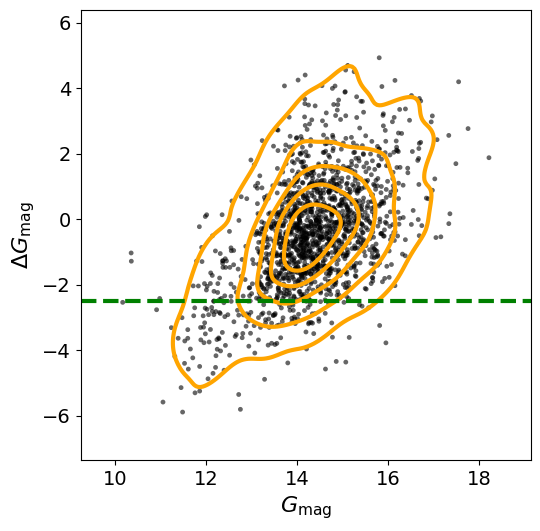

In [55]:
import seaborn as sns
# Obtener paleta accesible para daltónicos con 3 colores
palette = sns.color_palette("viridis", 12)
c1, c2, c3, c4, c5, c6, c7, c8, c9, c10, c11, c12 = palette

plt.figure(figsize=(5, 5))
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)

sns.scatterplot(data=df_parental, y="delta", x="Gmag", s=12,alpha=0.6, color="black", edgecolor='none')

sns.kdeplot(
    data=df_parental, x="Gmag", y="delta",
    levels=6, color="orange", linewidths=3
)

plt.axhline(y=-2.5, color='green', linestyle='--', linewidth=3)

plt.xlabel(r'$G_{\mathrm{mag}}$', fontsize=16)
plt.ylabel(r'$\Delta G_{\mathrm{mag}}$', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.savefig("contaminants.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [56]:
df_parental = df_parental.loc[df_parental["delta"]<=-2.5].reset_index(drop=True)

In [57]:
df_parental

,angDist,ID,database,ra,dec,TIC,RAdeg,DEdeg,HIP,TYC,...,E_Dist,RAOdeg,DEOdeg,l,b,sector_list,filenames,TPfPloter,sector_TPfPloter,delta
0,0.067300,OGLE-LMC-LPV-01700,3,70.579125,-69.349389,294665029,70.579095,-69.349373,0,NaN,...,1166.72,70.579121,-69.349375,-78.829334,-36.463647,"[61, 63, 64, 65, 67, 68, 69, 66]",['hlsp_tess-spoc_tess_phot_0000000294665029-s0...,Gaia_TIC294665029_S61.dat,61,-2.981918
1,0.171994,OGLE-GD-LPV-018950,4,279.060083,5.077750,106774563,279.060114,5.077786,0,NaN,...,990.90,279.060095,5.077727,35.735665,5.687355,[80],['hlsp_tess-spoc_tess_phot_0000000106774563-s0...,Gaia_TIC106774563_S80.dat,80,-4.396342
2,0.094161,OGLE-BLG-LPV-240065,4,262.688417,-37.138750,175626103,262.688429,-37.138774,0,NaN,...,NaN,262.688429,-37.138774,-8.595828,-1.756632,[66],['hlsp_tess-spoc_tess_phot_0000000175626103-s0...,Gaia_TIC175626103_S66.dat,66,-2.779309
3,0.143397,OGLE-GD-LPV-023882,4,285.853417,-0.543806,308333772,285.853421,-0.543766,0,NaN,...,1662.20,285.853400,-0.543796,33.813631,-2.912454,[80],['hlsp_tess-spoc_tess_phot_0000000308333772-s0...,Gaia_TIC308333772_S80.dat,80,-3.631010
4,0.076203,OGLE-GD-LPV-016593,4,255.770708,-43.162444,123396860,255.770688,-43.162460,0,NaN,...,NaN,255.770688,-43.162460,-16.565063,-0.934563,[66],['hlsp_tess-spoc_tess_phot_0000000123396860-s0...,Gaia_TIC123396860_S66.dat,66,-3.264166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,0.076645,OGLE-GD-LPV-022893,4,284.085875,-1.939722,57821571,284.085893,-1.939711,0,NaN,...,2432.02,284.085875,-1.939733,31.764005,-1.975474,[80],['hlsp_tess-spoc_tess_phot_0000000057821571-s0...,Gaia_TIC57821571_S80.dat,80,-4.018263
143,0.104969,OGLE-GD-LPV-022866,4,284.025292,2.847556,227287151,284.025287,2.847527,0,NaN,...,NaN,284.025287,2.847527,35.997566,0.261698,[80],['hlsp_tess-spoc_tess_phot_0000000227287151-s0...,Gaia_TIC227287151_S80.dat,80,-3.147010
144,0.137619,OGLE-GD-LPV-025295,4,288.268750,11.427778,206801793,288.268721,11.427752,0,NaN,...,NaN,288.268721,11.427752,45.551460,0.464665,"[80, 81]",['hlsp_tess-spoc_tess_phot_0000000206801793-s0...,Gaia_TIC206801793_S80.dat,80,-2.608999
145,0.139123,OGLE-SMC-LPV-17874,3,17.612208,-72.596861,402100419,17.612167,-72.596824,0,NaN,...,1555.97,17.612184,-72.596830,-59.057754,-44.457873,[68],['hlsp_tess-spoc_tess_phot_0000000402100419-s0...,Gaia_TIC402100419_S68.dat,68,-3.958240


In [58]:
df_parental.to_csv("catalogs/3_OGLEXTessV8_LC_DeltaMagnitude_Clean.csv",index=False)

## Guardar Curvas de luz

In [59]:
import sys
from astropy.io import fits
def convert_to_little_endian(arr):
    # Si el array ya es little-endian, lo retornamos sin cambios
    if arr.dtype.byteorder == '<' or (arr.dtype.byteorder == '=' and sys.byteorder == 'little'):
        return arr
    # De lo contrario, cambiamos el orden de los bytes
    else:
        return arr.byteswap().newbyteorder('<')

In [60]:
ls

1_TESS_variability_MassiveStarG12_preparate_data-Copy1.ipynb
1_TESS_variability_MassiveStarG12_preparate_data_OGLE.ipynb
2_Github_TESS_variability_MassiveStarG12.ipynb
3_HowToUse_CNN_BRF.ipynb
catalogs/
CheckAperture/
contaminants.pdf
cross_match_heatmap.pdf
cross_match_hist2d.pdf
cubos/
download_paralell/
environment.txt
lightcurves/
lightcurves_all.parquet
make_test_sample.py
ogle_download/
peaks_ls.parquet
peaks.parquet
peaks_single.parquet
periodograms_acf.parquet
periodograms_ls.parquet
test_data/
train_number_M.csv
xmatch_tic_result.fits


In [ ]:
import sys
from pathlib import Path

REPO_SRC = str(Path.cwd() / "src")
if REPO_SRC not in sys.path:
    sys.path.insert(0, REPO_SRC)

from msv.io import open_lc


In [64]:
import ray
import os
import ast
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from tqdm.auto import tqdm

PATH_DOWNLOAD = f'{DATA_ROOT}/ogle_download/'
OUT_PARQUET   = f'{DATA_ROOT}/lightcurves_all_OGLE.parquet'

if ray.is_initialized():
    ray.shutdown()
ray.init(num_cpus=24, ignore_reinit_error=True)

@ray.remote
def load_lc(TIC, sector, path_download=PATH_DOWNLOAD):
    try:
        df = open_lc(TIC, sector, path_download=path_download)
        df["TIC"] = int(TIC)
        df["sector"] = int(sector)
        return df
    except Exception as e:
        return f"ERROR {TIC}_{sector}: {e}"

parental_catalog = pd.read_csv("catalogs/3_OGLEXTessV8_LC_DeltaMagnitude_Clean.csv")
parental_catalog["sector_list"] = parental_catalog["sector_list"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
jobs = parental_catalog[["TIC", "sector_list"]].explode("sector_list").dropna()
jobs["sector_list"] = jobs["sector_list"].astype(int)
tasks = list(zip(jobs["TIC"].astype(int), jobs["sector_list"]))
print(f"Total tareas: {len(tasks)}")

# Lanza todas las tareas
futures = [load_lc.remote(tic, sec) for tic, sec in tasks]

# Consumir resultados conforme van llegando y escribir en streaming a un solo parquet
writer = None
errors = []
n_ok = 0
pending = futures
with tqdm(total=len(futures)) as pbar:
    while pending:
        done, pending = ray.wait(pending, num_returns=min(50, len(pending)))
        for res in ray.get(done):
            if isinstance(res, str):
                errors.append(res)
            else:
                table = pa.Table.from_pandas(res, preserve_index=False)
                if writer is None:
                    writer = pq.ParquetWriter(OUT_PARQUET, table.schema, compression="snappy")
                writer.write_table(table)
                n_ok += 1
            pbar.update(1)

if writer is not None:
    writer.close()

print(f"\n{n_ok} curvas escritas en {OUT_PARQUET}")
print(f"{len(errors)} errores")
if errors:
    print("Primeros:", errors[:5])

ray.shutdown()


2026-05-27 17:38:35,601	INFO worker.py:1752 -- Started a local Ray instance.


Total tareas: 263


  0%|          | 0/263 [00:00<?, ?it/s]

(load_lc pid=32402) Warning: 28% (3337/11719) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).



263 curvas escritas en /home/nicolas/nico/git/MassiveStarVariability/lightcurves_all_OGLE.parquet
0 errores


(load_lc pid=32398) Warning: 35% (3927/11157) of the cadences will be ignored due to the quality mask (quality_bitmask=65535). [repeated 89x across cluster]


In [87]:
df_parental

,angDist,ID,database,ra,dec,TIC,RAdeg,DEdeg,HIP,TYC,...,E_Dist,RAOdeg,DEOdeg,l,b,sector_list,filenames,TPfPloter,sector_TPfPloter,delta
0,0.067300,OGLE-LMC-LPV-01700,3,70.579125,-69.349389,294665029,70.579095,-69.349373,0,NaN,...,1166.72,70.579121,-69.349375,-78.829334,-36.463647,"[61, 63, 64, 65, 67, 68, 69, 66]",['hlsp_tess-spoc_tess_phot_0000000294665029-s0...,Gaia_TIC294665029_S61.dat,61,-2.981918
1,0.171994,OGLE-GD-LPV-018950,4,279.060083,5.077750,106774563,279.060114,5.077786,0,NaN,...,990.90,279.060095,5.077727,35.735665,5.687355,[80],['hlsp_tess-spoc_tess_phot_0000000106774563-s0...,Gaia_TIC106774563_S80.dat,80,-4.396342
2,0.094161,OGLE-BLG-LPV-240065,4,262.688417,-37.138750,175626103,262.688429,-37.138774,0,NaN,...,NaN,262.688429,-37.138774,-8.595828,-1.756632,[66],['hlsp_tess-spoc_tess_phot_0000000175626103-s0...,Gaia_TIC175626103_S66.dat,66,-2.779309
3,0.143397,OGLE-GD-LPV-023882,4,285.853417,-0.543806,308333772,285.853421,-0.543766,0,NaN,...,1662.20,285.853400,-0.543796,33.813631,-2.912454,[80],['hlsp_tess-spoc_tess_phot_0000000308333772-s0...,Gaia_TIC308333772_S80.dat,80,-3.631010
4,0.076203,OGLE-GD-LPV-016593,4,255.770708,-43.162444,123396860,255.770688,-43.162460,0,NaN,...,NaN,255.770688,-43.162460,-16.565063,-0.934563,[66],['hlsp_tess-spoc_tess_phot_0000000123396860-s0...,Gaia_TIC123396860_S66.dat,66,-3.264166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,0.076645,OGLE-GD-LPV-022893,4,284.085875,-1.939722,57821571,284.085893,-1.939711,0,NaN,...,2432.02,284.085875,-1.939733,31.764005,-1.975474,[80],['hlsp_tess-spoc_tess_phot_0000000057821571-s0...,Gaia_TIC57821571_S80.dat,80,-4.018263
143,0.104969,OGLE-GD-LPV-022866,4,284.025292,2.847556,227287151,284.025287,2.847527,0,NaN,...,NaN,284.025287,2.847527,35.997566,0.261698,[80],['hlsp_tess-spoc_tess_phot_0000000227287151-s0...,Gaia_TIC227287151_S80.dat,80,-3.147010
144,0.137619,OGLE-GD-LPV-025295,4,288.268750,11.427778,206801793,288.268721,11.427752,0,NaN,...,NaN,288.268721,11.427752,45.551460,0.464665,"[80, 81]",['hlsp_tess-spoc_tess_phot_0000000206801793-s0...,Gaia_TIC206801793_S80.dat,80,-2.608999
145,0.139123,OGLE-SMC-LPV-17874,3,17.612208,-72.596861,402100419,17.612167,-72.596824,0,NaN,...,1555.97,17.612184,-72.596830,-59.057754,-44.457873,[68],['hlsp_tess-spoc_tess_phot_0000000402100419-s0...,Gaia_TIC402100419_S68.dat,68,-3.958240


In [86]:
df_parental.loc[df_parental["ID"].str.split("-").str[2]=="RR"]

,angDist,ID,database,ra,dec,TIC,RAdeg,DEdeg,HIP,TYC,...,E_Dist,RAOdeg,DEOdeg,l,b,sector_list,filenames,TPfPloter,sector_TPfPloter,delta


TIC 464936311 - sector 10: 1039 puntos


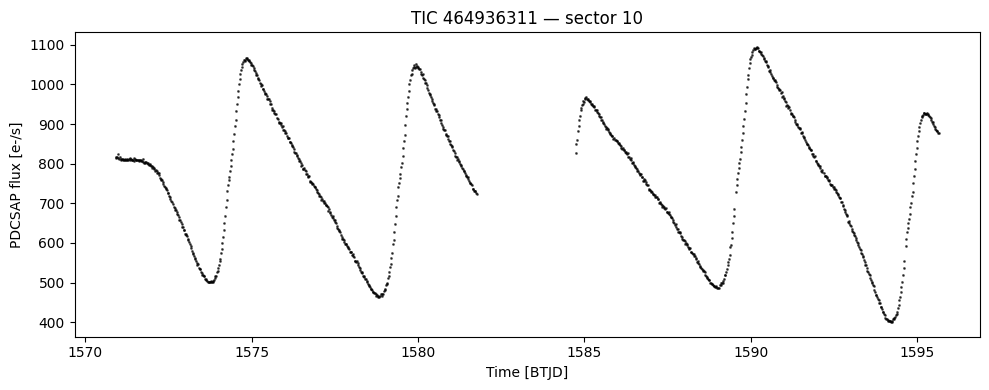

In [85]:
import pandas as pd
import matplotlib.pyplot as plt

OUT_PARQUET = f'{DATA_ROOT}/lightcurves_all_OGLE.parquet'

TIC    = 464936311
sector = 10

# Lee solo las filas de ese TIC+sector (push-down filter, no carga el resto)
lc = pd.read_parquet(
    OUT_PARQUET,
    filters=[("TIC", "=", TIC), ("sector", "=", sector)],
    columns=["Time", "flux", "flux_err"],
)

print(f"TIC {TIC} - sector {sector}: {len(lc)} puntos")

fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(lc["Time"], lc["flux"], yerr=lc["flux_err"],
            fmt='.', ms=2, elinewidth=0.3, color='k', alpha=0.6)
ax.set_xlabel("Time [BTJD]")
ax.set_ylabel("PDCSAP flux [e-/s]")
ax.set_title(f"TIC {TIC} — sector {sector}")
plt.tight_layout()
plt.show()
